In [ ]:
from langchain_community.tools import ShellTool
from typing import Optional
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser, JsonOutputParser, StrOutputParser
from langsmith import traceable
from tavily import TavilyClient
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
from pprint import pprint
# from tenacity import retry, stop_after_attempt
load_dotenv()  # Load environment variables from .env file


True

In [42]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gptoss",

    base_url="http://127.0.0.1:8000/v1",

    api_key="dummy",

    temperature=0.3,

    max_retries=0,
)




In [43]:
import dspy

lm = dspy.LM(
    "openai/gptoss",
    api_base="http://127.0.0.1:8000/v1",
    api_key="dummy",
    temperature=0.3,
    cache=False,
    num_retries=0,
)

dspy.configure(lm=lm)


In [44]:
class state(BaseModel):
    query: str = Field(description="The query to be processed by the model.")
    todo_list : Optional[dict]  = Field(default={}, description="write the to do list to be done for this task")
    code : Optional[dict] = Field(default = {}, description="The code generated by the model in response to the query.")
    command : Optional[dict] = Field(default = {}, description="The command generated by the model in response to read or write the code.")
    error : Optional[str] = Field(default=None,description="The error casused")
    test_cases : Optional[str] = Field(default = None, description="The test cases generated by the model for the code.")
    current_step : Optional[int] = Field(default=None, description="Current step for executing codes")
    is_implemented : Optional[bool] = Field(default=None, description="entire is implemented or not")


In [45]:
@traceable
def create_todotask(state_obj : state):
    print("state at create todotask", state_obj)

    template = """
You are an expert software architect and project manager.

Your task is to break down a given project into a highly modular
folder structure and provide a step-by-step to-do list for implementation.

Each step should correspond to a module, Python file, or logical component
in an appropriate directory.

Orchestrate the tasks so they can later be used for code generation.

Do exactly what is requested. Do not add unnecessary functionality,
especially deployment-related components unless explicitly requested.

Keep the architecture as simple and short as possible.

Start the project inside the "agent/" directory.

Return EXCLUSIVELY a valid JSON object.
Do not return markdown.
Do not return ```json.
Do not return explanations outside the JSON.
Do not return comments inside the JSON.

If asked for UI, create in html and css in proper place

The response MUST follow this structure:

{{
    "project_name": "Name of the project",
    "architecture_summary": "A concise 1-2 sentence architecture summary",
    "folder_structure": {{
        "agent": {{
            "example_module.py": "Description of this file"
        }}
    }},
    "todo_list": [
        {{
            "step_number": 1,
            "task_name": "Name of the task",
            "description": "Detailed description of what must be implemented with the technology",
            "target_file_or_folder": "agent/example_module.py",
            "dependencies": [1,3],
            "is_implemented": null
        }}
    ]
}}

PROJECT TASK:
{input_query}
"""
    output_parser = JsonOutputParser()
    prompt = PromptTemplate(
        template=template,
        input_variables=['input_query'],
    )
    chain = prompt | llm | output_parser
    result = chain.invoke({"input_query" : state_obj.query})
    state_obj.todo_list = result
    return state_obj



In [46]:
def redirect(state_obj : state):

    print("state at redirect", state_obj)

    
    todo_list = state_obj.todo_list['todo_list']
    

    for ind,todo in enumerate(todo_list):
        if todo['is_implemented'] is None:
            state_obj.current_step = ind
            return state_obj
    state_obj.is_implemented = True
    return state_obj

In [ ]:
class transform_code(dspy.Signature):
    """Generate content only for the requested target file."""

    input_task = dspy.InputField(
        desc="Exact task that must be implemented"
    )
    target_file = dspy.InputField(
        desc="Exact file receiving the generated content"
    )
    
    existing_code = dspy.InputField(
        desc="Dependency code for reference only; do not reproduce it"
    )
    current_file_content = dspy.InputField(
        desc="Existing content of the target file, empty for a new file"
    )
    feedback_str = dspy.InputField(
            des = "feedback for previously genearted code to the LLM so that it can generate better"
        )
    current_codeissue = dspy.InputField(
            desc="the current code to be fixed"
        )
    code = dspy.OutputField(
        desc=(
            "Return only the complete content for target_file. "
            "Do not generate other files, file labels, Markdown fences, "
            "or dependency code."
        )
    )


class validate(dspy.Signature):

    input_code : str = dspy.InputField(
        desc="Exact task that must be implemented"
    )
    feedback_score : float = dspy.OutputField(
        desc="code quality for the input generated code between 0 and 1"
    )
    feedback_str : str = dspy.OutputField(
        desc="summarised feedback for the generated codes"
    )

In [54]:
def remove_markdown_from_code(code:str):
    code = code.strip()

    if not code.startswith("```"):
        return code

    lines = code.splitlines()
    if lines[0].startswith("```"):
        lines = lines[1:]
    if lines[-1].startswith("```"):
        lines = lines[:-1]

    return '\n'.join(lines)

In [ ]:

    
@traceable
def implement_code(state_obj:state):
    print("state at create implement code", state_obj)

    current_step = state_obj.current_step
    current_task = state_obj.todo_list["todo_list"][current_step]
    target_file = current_task["target_file_or_folder"]

    existing_codesreq = {"step_number_"+str(i) : state_obj.code["step_number_" + str(i)] for i in state_obj.todo_list['todo_list'][current_step]["dependencies"]}
    feedback = "no previous code generated"
    current_code = "nothing now"

    validate_code = dspy.ChainOfThought(validate)
    generate_code = dspy.ChainOfThought(transform_code)

    n = 5
    for i in range(1,n+1):
        print(f"______ trial {i} __________")
        response = generate_code(
            input_task=current_task["description"],
            target_file=target_file,
            existing_code=existing_codesreq,
            current_file_content="",
            feedback_str = feedback,
            current_codeissue = current_code
        )
        
        current_code = remove_markdown_from_code(response.code)
        validation = validate_code(input_code = current_code)
        print(f"validation score {validation.feedback_score}")
        feedback = validation.feedback_str
        # current_code = response.code
        if i<n and validation.feedback_score >=0.8:
            break
    state_obj.code["step_number_" + str(state_obj.todo_list['todo_list'][current_step]["step_number"])] = current_code
    return state_obj



In [56]:
@traceable
def implement_command(state_obj:state):

    print("state at create implement command", state_obj)

    current_step = state_obj.current_step
    current_task = state_obj.todo_list['todo_list'][current_step]
    generated_code = state_obj.code['step_number_' + str(current_task["step_number"]) ]

    current_file = current_task['target_file_or_folder']
    if len(current_file.split('/'))>1:
        folder = '/'.join(current_file.split('/')[:-1])
    else:
        folder = " "
    ShellTool().invoke(f"""mkdir -p {folder} && cat > {current_file} << 'EOF'
{generated_code} """)
    state_obj.todo_list['todo_list'][current_step]['is_implemented'] = True


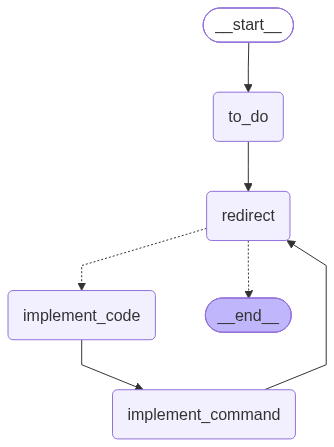

In [57]:
workflow = StateGraph(state)
workflow.add_node("to_do",create_todotask)
workflow.add_node("redirect",redirect)
workflow.add_node("implement_code",implement_code)
workflow.add_node("implement_command",implement_command)

workflow.add_edge(START, "to_do")
workflow.add_edge("to_do","redirect")


def route_to_next_task(state_obj: state):
    if not state_obj.is_implemented:
        return "implement_code"
    return END

workflow.add_conditional_edges(
    "redirect",
    route_to_next_task,
    {
        "implement_code":"implement_code",
        END:END
    }
    
)
workflow.add_edge("implement_code","implement_command")
workflow.add_edge("implement_command","redirect")

agent = workflow.compile()

display(Image(agent.get_graph().draw_mermaid_png()))


In [58]:
query1 = "write a code to check if a number is prime or not with web page ui"
query2 = "Build a library management system with modules for books, members, borrowing, and reporting with webpage ui."
query3 = "Create a weather application with separate modules for API access, caching, data processing, and UI properly."
query4 = "Develop an e-commerce backend with authentication, products, cart, orders, and payments."
query5 = "Build a Flask to-do application with routes, services, HTML templates, CSS, and in-memory storage."
agent.invoke({"query":query1})

state at create todotask query='write a code to check if a number is prime or not with web page ui' todo_list={} code={} command={} error=None test_cases=None current_step=None is_implemented=None
state at redirect query='write a code to check if a number is prime or not with web page ui' todo_list={'project_name': 'Prime Number Checker Web App', 'architecture_summary': 'A lightweight Flask backend with a utility module for prime checking and a simple HTML/CSS frontend for user interaction.', 'folder_structure': {'agent': {'app.py': 'Flask application entry point handling routes and UI integration', 'utils': {'prime.py': 'Utility module containing the function to determine if a number is prime'}, 'templates': {'index.html': 'HTML page with a form to input a number and display the result'}, 'static': {'style.css': 'CSS stylesheet for basic styling of the web page'}}}, 'todo_list': [{'step_number': 1, 'task_name': 'Create project skeleton', 'description': 'Create the agent directory with

/Users/jyostnabanik/AI Agents/.agent/lib/python3.14/site-packages/langchain_community/tools/shell/tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


validation score 0.93
state at create implement command query='write a code to check if a number is prime or not with web page ui' todo_list={'project_name': 'Prime Number Checker Web App', 'architecture_summary': 'A lightweight Flask backend with a utility module for prime checking and a simple HTML/CSS frontend for user interaction.', 'folder_structure': {'agent': {'app.py': 'Flask application entry point handling routes and UI integration', 'utils': {'prime.py': 'Utility module containing the function to determine if a number is prime'}, 'templates': {'index.html': 'HTML page with a form to input a number and display the result'}, 'static': {'style.css': 'CSS stylesheet for basic styling of the web page'}}}, 'todo_list': [{'step_number': 1, 'task_name': 'Create project skeleton', 'description': 'Create the agent directory with subfolders utils, templates, static and placeholder files app.py, prime.py, index.html, and style.css.', 'target_file_or_folder': 'agent/', 'dependencies': []

{'query': 'write a code to check if a number is prime or not with web page ui',
 'todo_list': {'project_name': 'Prime Number Checker Web App',
  'architecture_summary': 'A lightweight Flask backend with a utility module for prime checking and a simple HTML/CSS frontend for user interaction.',
  'folder_structure': {'agent': {'app.py': 'Flask application entry point handling routes and UI integration',
    'utils': {'prime.py': 'Utility module containing the function to determine if a number is prime'},
    'templates': {'index.html': 'HTML page with a form to input a number and display the result'},
    'static': {'style.css': 'CSS stylesheet for basic styling of the web page'}}},
  'todo_list': [{'step_number': 1,
    'task_name': 'Create project skeleton',
    'description': 'Create the agent directory with subfolders utils, templates, static and placeholder files app.py, prime.py, index.html, and style.css.',
    'target_file_or_folder': 'agent/',
    'dependencies': [],
    'is_imp